<a href="https://colab.research.google.com/github/zhuldyzboshanova03-rgb/TB-RNAseq-analysis/blob/main/TB_RNAseq_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
  print("Hello, bioinformatics!")

Hello, bioinformatics!


In [2]:
import pandas as pd, gzip, urllib.request

# 1. Gene counts (NCBI-generated raw counts)
counts_url = "https://www.ncbi.nlm.nih.gov/geo/download/?type=rnaseq_counts&acc=GSE101705&format=file&file=GSE101705_raw_counts_GRCh38.p13_NCBI.tsv.gz"
counts = pd.read_csv(counts_url, sep="\t", index_col=0)

# 2. Sample info: which samples are TB and which are LTBI
matrix_url = "https://ftp.ncbi.nlm.nih.gov/geo/series/GSE101nnn/GSE101705/matrix/GSE101705_series_matrix.txt.gz"
urllib.request.urlretrieve(matrix_url, "matrix.txt.gz")
for line in gzip.open("matrix.txt.gz", "rt"):
    if line.startswith("!Sample_title"):
        titles = [x.strip('"\n') for x in line.split("\t")[1:]]
    if line.startswith("!Sample_geo_accession"):
        ids = [x.strip('"\n') for x in line.split("\t")[1:]]
metadata = pd.DataFrame({"sample": ids, "title": titles})
metadata["condition"] = metadata["title"].str.split("_").str[0]
metadata = metadata.set_index("sample")

print("Counts table:", counts.shape[0], "genes x", counts.shape[1], "samples")
print(metadata["condition"].value_counts())
metadata.head()

Counts table: 39376 genes x 44 samples
condition
TB      28
LTBI    16
Name: count, dtype: int64


,title,condition
sample,,
GSM2712676,TB_1,TB
GSM2712677,TB_2,TB
GSM2712678,TB_3,TB
GSM2712679,TB_4,TB
GSM2712680,TB_5,TB


Reads per sample: min 30858324 | median 39052722 | max 52849243
Genes before filtering: 39376 | after: 19306


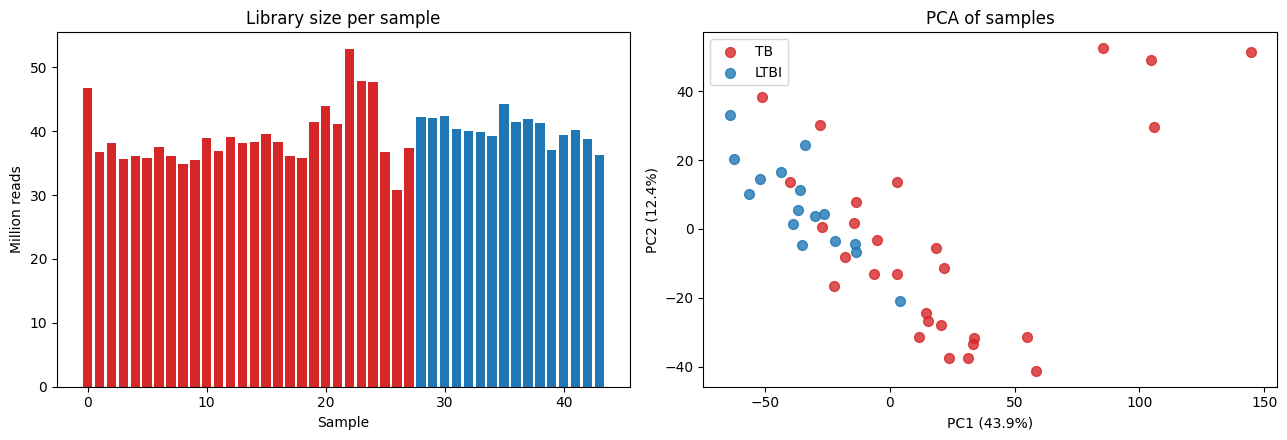

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# 1. Library size: total reads per sample
lib_size = counts.sum(axis=0)
print("Reads per sample: min", int(lib_size.min()), "| median", int(lib_size.median()), "| max", int(lib_size.max()))

# 2. Remove genes that are almost never expressed
keep = (counts >= 10).sum(axis=1) >= 10       # at least 10 reads in at least 10 samples
counts_filt = counts[keep]
print("Genes before filtering:", counts.shape[0], "| after:", counts_filt.shape[0])

# 3. Normalize (counts per million) and log-transform
cpm = counts_filt / counts_filt.sum(axis=0) * 1e6
logcpm = np.log2(cpm + 1)

# 4. PCA: do TB and LTBI samples separate?
pcs = PCA(n_components=2).fit(logcpm.T)
coords = pcs.transform(logcpm.T)
var = pcs.explained_variance_ratio_ * 100

colors = metadata.loc[logcpm.columns, "condition"].map({"TB": "#d62728", "LTBI": "#1f77b4"})
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].bar(range(len(lib_size)), lib_size / 1e6, color=colors)
axes[0].set(title="Library size per sample", xlabel="Sample", ylabel="Million reads")
for cond, c in [("TB", "#d62728"), ("LTBI", "#1f77b4")]:
    m = (colors == c).values
    axes[1].scatter(coords[m, 0], coords[m, 1], c=c, label=cond, s=50, alpha=0.8)
axes[1].set(title="PCA of samples", xlabel=f"PC1 ({var[0]:.1f}%)", ylabel=f"PC2 ({var[1]:.1f}%)")
axes[1].legend()
plt.tight_layout()
plt.savefig("qc_plots.png", dpi=150)
plt.show()

In [4]:
!pip -q install pydeseq2 mygene "anndata==0.11.4" "zarr<3"

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.3/211.3 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 28.9 MB/s eta 0:00:00


In [5]:
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats
import mygene

# 1. Differential expression: TB vs LTBI
dds = DeseqDataSet(
    counts=counts_filt.T,                          # samples as rows, genes as columns
    metadata=metadata.loc[counts_filt.columns],
    design="~condition",
)
dds.deseq2()                                       # normalization + statistical model for every gene

stats = DeseqStats(dds, contrast=["condition", "TB", "LTBI"])   # LTBI = reference group
stats.summary()
results = stats.results_df

# 2. Add gene names (GeneID -> symbol)
mg = mygene.MyGeneInfo()
ann = mg.querymany(results.index.astype(str).tolist(), scopes="entrezgene",
                   fields="symbol,name", species="human", as_dataframe=True, verbose=False)
ann = ann[~ann.index.duplicated()]
results["symbol"] = ann["symbol"].reindex(results.index.astype(str)).values
results["name"] = ann["name"].reindex(results.index.astype(str)).values
results = results.sort_values("padj")

# 3. Significant genes
sig = results[(results["padj"] < 0.05) & (results["log2FoldChange"].abs() > 1)]
print("Significant genes (padj < 0.05, |log2FC| > 1):", len(sig))
print("  Up in TB:  ", (sig["log2FoldChange"] > 0).sum())
print("  Down in TB:", (sig["log2FoldChange"] < 0).sum())

results.to_csv("DE_results_TB_vs_LTBI.csv")
sig[["symbol", "name", "log2FoldChange", "padj"]].head(20)

/usr/local/lib/python3.13/dist-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
Fitting size factors...


Using None as control genes, passed at DeseqDataSet initialization


... done in 0.19 seconds.

Fitting dispersions...
... done in 35.20 seconds.

Fitting dispersion trend curve...
... done in 0.80 seconds.

Fitting MAP dispersions...
... done in 41.58 seconds.

Fitting LFCs...
... done in 18.75 seconds.

Calculating cook's distance...
... done in 0.10 seconds.

Replacing 40 outlier genes.

Fitting dispersions...
... done in 0.14 seconds.

Fitting MAP dispersions...
... done in 0.12 seconds.

Fitting LFCs...
... done in 0.09 seconds.

Running Wald tests...
... done in 6.77 seconds.



Log2 fold change & Wald test p-value: condition TB vs LTBI
               baseMean  log2FoldChange     lfcSE      stat    pvalue  \
GeneID                                                                  
100287102     65.295382        0.146521  0.295822  0.495302  0.620387   
653635       803.502040        0.413925  0.194703  2.125931  0.033509   
102466751     37.188010       -0.120734  0.161187 -0.749032  0.453838   
100996442    366.549203        0.249167  0.205447  1.212806  0.225204   
729737     13898.295273        0.793089  0.204274  3.882478  0.000103   
...                 ...             ...       ...       ...       ...   
4541       19260.880595        0.028377  0.217546  0.130443  0.896216   
4556         835.319541        0.240549  0.275455  0.873278  0.382512   
4519       58540.431703        0.091717  0.211512  0.433626  0.664560   
4576         183.065669        1.049982  0.261107  4.021271  0.000058   
4571          76.027938        0.475823  0.202417  2.350715  0.01

,symbol,name,log2FoldChange,padj
GeneID,,,,
116071,BATF2,basic leucine zipper ATF-like transcription fa...,3.457805,9.130639e-25
118932,ANKRD22,ankyrin repeat domain 22,3.466091,3.632006e-21
80832,APOL4,apolipoprotein L4,3.172590,5.163986e-20
2209,FCGR1A,Fc gamma receptor Ia,3.010802,6.330862e-18
10577,NPC2,NPC intracellular cholesterol transporter 2,1.285095,1.344957e-17
340654,LIPM,lipase family member M,3.268274,1.344957e-17
710,SERPING1,serpin family G member 1,3.032580,2.306292e-17
100132417,FCGR1CP,"Fc gamma receptor Ic, pseudogene",2.947799,3.009222e-17
5414,SEPTIN4,septin 4,2.985901,4.600129e-16


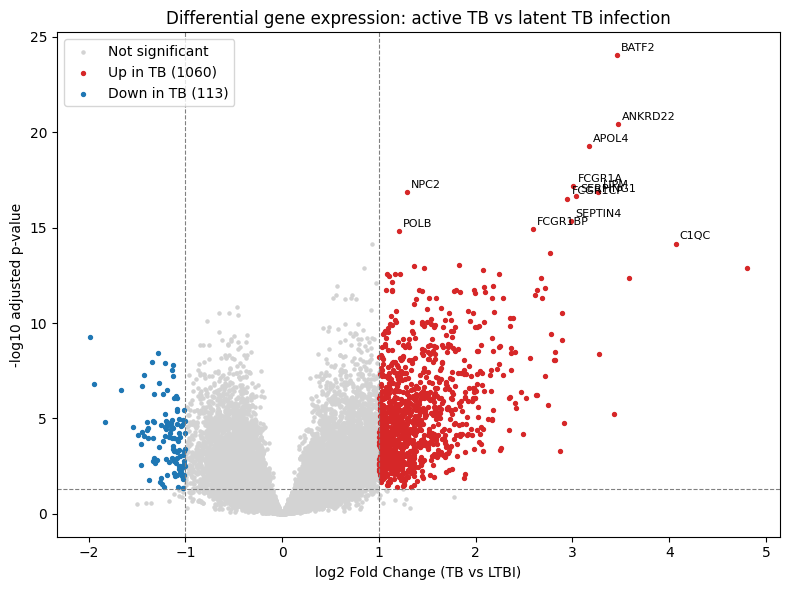

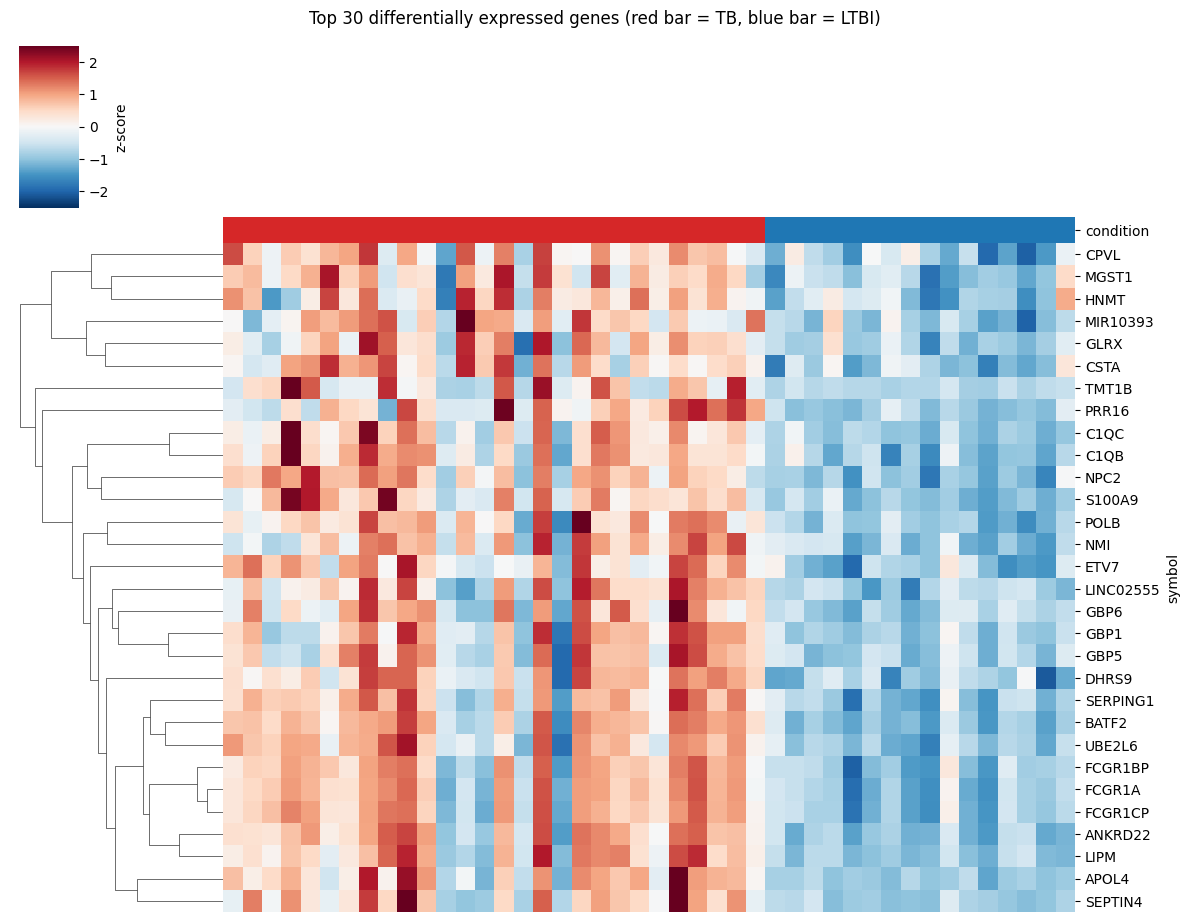

In [6]:
import seaborn as sns
logcpm.index = logcpm.index.astype(str)          # make gene IDs the same type as in results

# ---------- 1. Volcano plot ----------
res = results.dropna(subset=["padj"]).copy()
res["neglog10padj"] = -np.log10(res["padj"])
up   = (res["padj"] < 0.05) & (res["log2FoldChange"] > 1)
down = (res["padj"] < 0.05) & (res["log2FoldChange"] < -1)

plt.figure(figsize=(8, 6))
plt.scatter(res.loc[~(up | down), "log2FoldChange"], res.loc[~(up | down), "neglog10padj"], s=5, c="lightgrey", label="Not significant")
plt.scatter(res.loc[up, "log2FoldChange"], res.loc[up, "neglog10padj"], s=8, c="#d62728", label=f"Up in TB ({up.sum()})")
plt.scatter(res.loc[down, "log2FoldChange"], res.loc[down, "neglog10padj"], s=8, c="#1f77b4", label=f"Down in TB ({down.sum()})")
for _, row in res[up | down].nsmallest(12, "padj").iterrows():      # label top 12 genes
    plt.annotate(row["symbol"], (row["log2FoldChange"], row["neglog10padj"]), fontsize=8, xytext=(3, 3), textcoords="offset points")
plt.axhline(-np.log10(0.05), ls="--", c="grey", lw=0.8)
plt.axvline(1, ls="--", c="grey", lw=0.8); plt.axvline(-1, ls="--", c="grey", lw=0.8)
plt.xlabel("log2 Fold Change (TB vs LTBI)"); plt.ylabel("-log10 adjusted p-value")
plt.title("Differential gene expression: active TB vs latent TB infection")
plt.legend(); plt.tight_layout()
plt.savefig("volcano_plot.png", dpi=150); plt.show()

# ---------- 2. Heatmap of top 30 genes ----------
top = res[up | down].nsmallest(30, "padj")
data = logcpm.loc[top.index]
data.index = top["symbol"].fillna(top.index.to_series().astype(str))
data = data.sub(data.mean(axis=1), axis=0).div(data.std(axis=1), axis=0)   # z-score per gene

order = metadata.loc[logcpm.columns].sort_values("condition", ascending=False).index
col_colors = metadata.loc[order, "condition"].map({"TB": "#d62728", "LTBI": "#1f77b4"})
g = sns.clustermap(data[order], col_cluster=False, col_colors=col_colors, cmap="RdBu_r",
                   center=0, vmin=-2.5, vmax=2.5, figsize=(12, 9), xticklabels=False,
                   cbar_kws={"label": "z-score"})
g.fig.suptitle("Top 30 differentially expressed genes (red bar = TB, blue bar = LTBI)", y=1.02)
g.savefig("heatmap_top30.png", dpi=150, bbox_inches="tight"); plt.show()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.7/689.7 kB 3.7 MB/s eta 0:00:00
Up-regulated genes sent to Enrichr: 1027


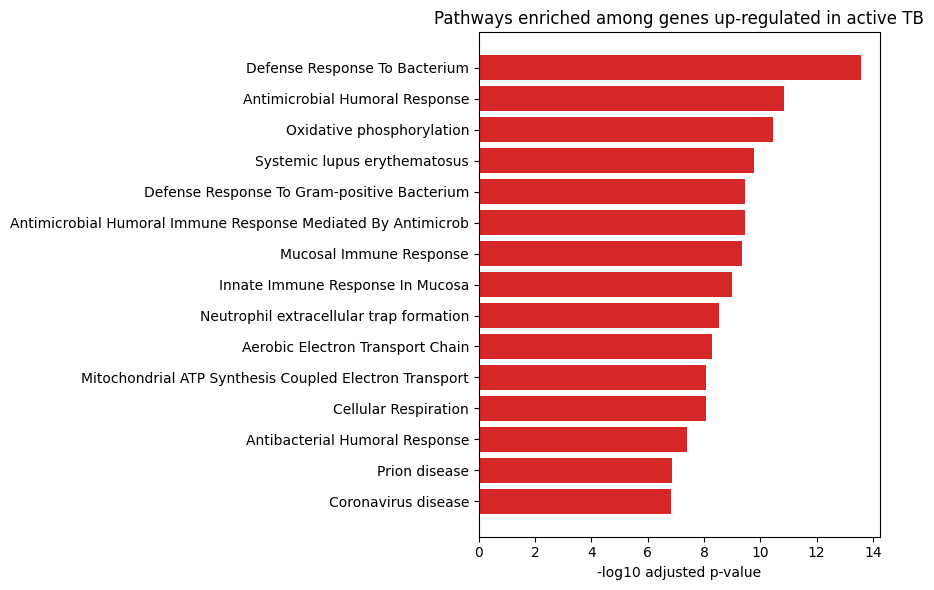

,Gene_set,Term,Overlap,Adjusted P-value
0,GO_Biological_Process_2023,Defense Response To Bacterium (GO:0042742),46/204,2.685238e-14
1,GO_Biological_Process_2023,Antimicrobial Humoral Response (GO:0019730),29/100,1.412702e-11
2769,KEGG_2021_Human,Oxidative phosphorylation,32/133,3.631743e-11
2770,KEGG_2021_Human,Systemic lupus erythematosus,31/135,1.664603e-10
2,GO_Biological_Process_2023,Defense Response To Gram-positive Bacterium (G...,25/85,3.492820e-10
3,GO_Biological_Process_2023,Antimicrobial Humoral Immune Response Mediated...,22/65,3.492820e-10
4,GO_Biological_Process_2023,Mucosal Immune Response (GO:0002385),15/28,4.549751e-10
5,GO_Biological_Process_2023,Innate Immune Response In Mucosa (GO:0002227),13/21,1.024793e-09
2771,KEGG_2021_Human,Neutrophil extracellular trap formation,35/189,2.878386e-09
6,GO_Biological_Process_2023,Aerobic Electron Transport Chain (GO:0019646),21/68,5.048036e-09


In [7]:
!pip -q install gseapy
import gseapy as gp

# Genes that go UP in active TB
up_genes = sig.loc[sig["log2FoldChange"] > 0, "symbol"].dropna().astype(str).tolist()
print("Up-regulated genes sent to Enrichr:", len(up_genes))

# Which biological processes / pathways are over-represented?
enr = gp.enrichr(gene_list=up_genes,
                 gene_sets=["GO_Biological_Process_2023", "KEGG_2021_Human"],
                 organism="human", outdir=None)
pathways = enr.results.sort_values("Adjusted P-value")
pathways.to_csv("pathway_enrichment_up_in_TB.csv", index=False)

# Plot top 15 terms
top15 = pathways.head(15).iloc[::-1]
labels = top15["Term"].str.replace(r"\s*\(GO:\d+\)", "", regex=True).str.slice(0, 60)
plt.figure(figsize=(9, 6))
plt.barh(labels, -np.log10(top15["Adjusted P-value"]), color="#d62728")
plt.xlabel("-log10 adjusted p-value")
plt.title("Pathways enriched among genes up-regulated in active TB")
plt.tight_layout()
plt.savefig("pathway_enrichment.png", dpi=150); plt.show()

pathways[["Gene_set", "Term", "Overlap", "Adjusted P-value"]].head(15)